# <a id='toc1_'></a>[Make naive predictions for each variable](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Make naive predictions for each variable](#toc1_)    
    - [Import + Setup](#toc1_1_1_)    
    - [Data upload](#toc1_1_2_)    
    - [Utility functions](#toc1_1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

### <a id='toc1_1_1_'></a>[Import + Setup](#toc0_)

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import src.utils as utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

UNUSABLE = [
    "Rural population living in areas where elevation is below 5 meters (% of total population)",
    "Access to electricity, rural (% of rural population)",
    "Surface area (sq. km)",
    "Rural land area (sq. km)",
    "Land area (sq. km)",
    "Average precipitation in depth (mm per year)",
    "Agricultural irrigated land (% of total agricultural land)",
    "Rural land area where elevation is below 5 meters (% of total land area)",
    "Rural land area where elevation is below 5 meters (sq. km)"
]

### <a id='toc1_1_2_'></a>[Data upload](#toc0_)

In [18]:
df = utils.load_data()

Dataset caricato: 65 anni, 28 variabili.


### <a id='toc1_1_3_'></a>[Utility functions](#toc0_)

In [23]:
def historical_mean(col, df):
    series = df[['Year', col]].rename(columns={col: 'Value'}).dropna(subset=['Value']).reset_index(drop=True)
    if series.empty:
        print(f"Skipping {col}: no data")
        return
    
    split_idx = int(len(series) * 0.8)
    if split_idx == 0 or split_idx >= len(series):
        print(f"Skipping {col}: not enough data for train/test split (n={len(series)})")
        return
    train = series.iloc[:split_idx].copy().dropna()
    test = series.iloc[split_idx:].copy()

    hist_mean = train['Value'].mean()
    print(f"{col} - historical mean (train {len(train)} values): {hist_mean}")
    test['pred_mean'] = hist_mean
    
    return train, test

Agricultural land (% of land area) - historical mean (train 49 values): 58.211056181127354


{'RMSE': np.float64(13.9339), 'MAE': 13.7994, 'MAPE': np.float64(31.31)}

RMSE (test 13 values): 13.9339
MAE (test 13 values): 13.7994
MAPE (test 13 values): 31.31%
Metriche salvate per HISTMEAN su Agricultural land (% of land area)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_agriland_percent.png


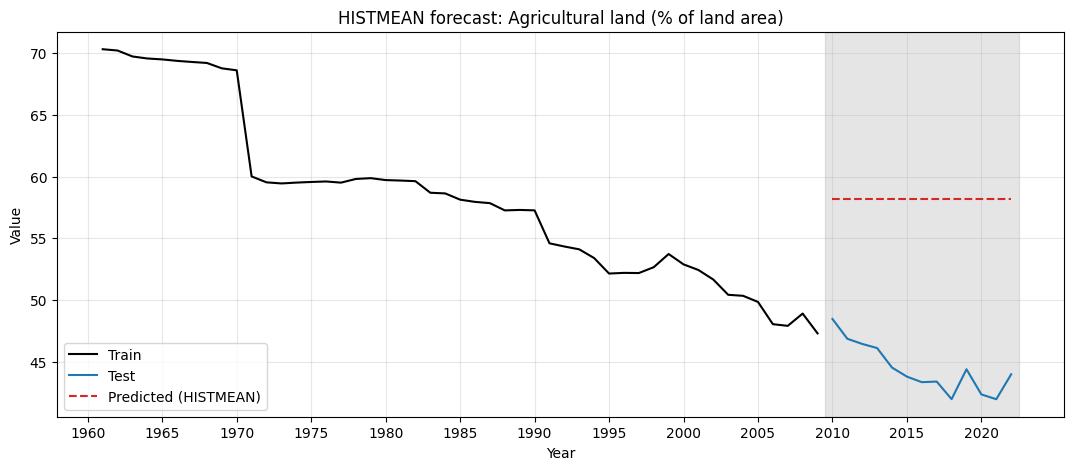

Agricultural land (sq. km) - historical mean (train 48 values): 172025.66666666666


{'RMSE': np.float64(40403.5215), 'MAE': 39937.4106, 'MAPE': np.float64(30.51)}

RMSE (test 13 values): 40403.5215
MAE (test 13 values): 39937.4106
MAPE (test 13 values): 30.51%
Metriche salvate per HISTMEAN su Agricultural land (sq. km)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_agriland_abs.png


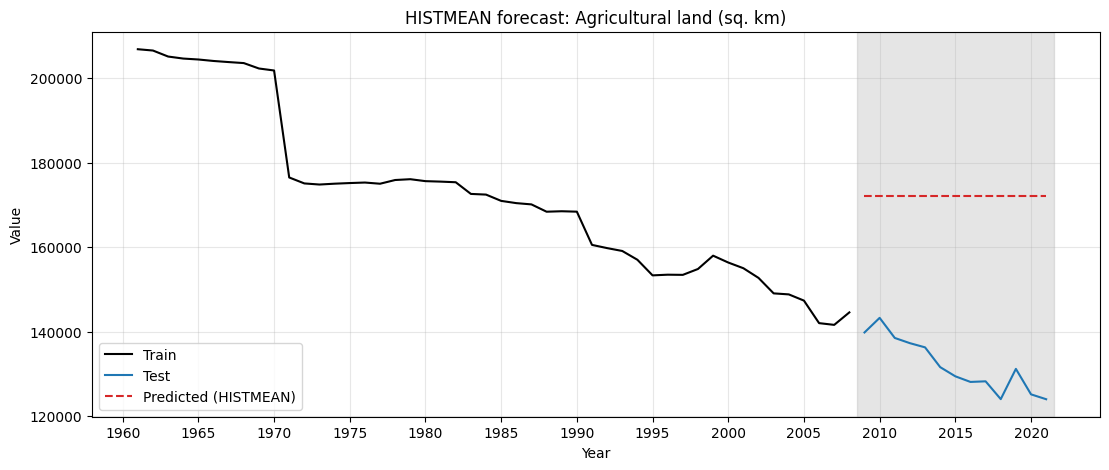

Agricultural raw materials exports (% of merchandise exports) - historical mean (train 50 values): 1.1585668260028044


{'RMSE': np.float64(0.4551), 'MAE': 0.4537, 'MAPE': np.float64(64.77)}

RMSE (test 13 values): 0.4551
MAE (test 13 values): 0.4537
MAPE (test 13 values): 64.77%
Metriche salvate per HISTMEAN su Agricultural raw materials exports (% of merchandise exports)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_exports_percent.png


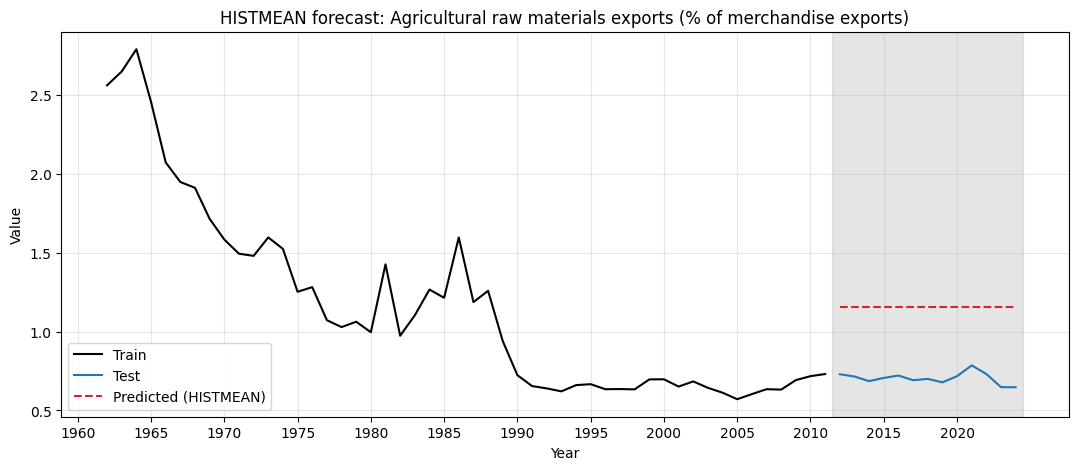

Agricultural raw materials imports (% of merchandise imports) - historical mean (train 50 values): 6.886714012369014


{'RMSE': np.float64(4.9097), 'MAE': 4.9025, 'MAPE': np.float64(253.3)}

RMSE (test 13 values): 4.9097
MAE (test 13 values): 4.9025
MAPE (test 13 values): 253.30%
Metriche salvate per HISTMEAN su Agricultural raw materials imports (% of merchandise imports)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_imports_percent.png


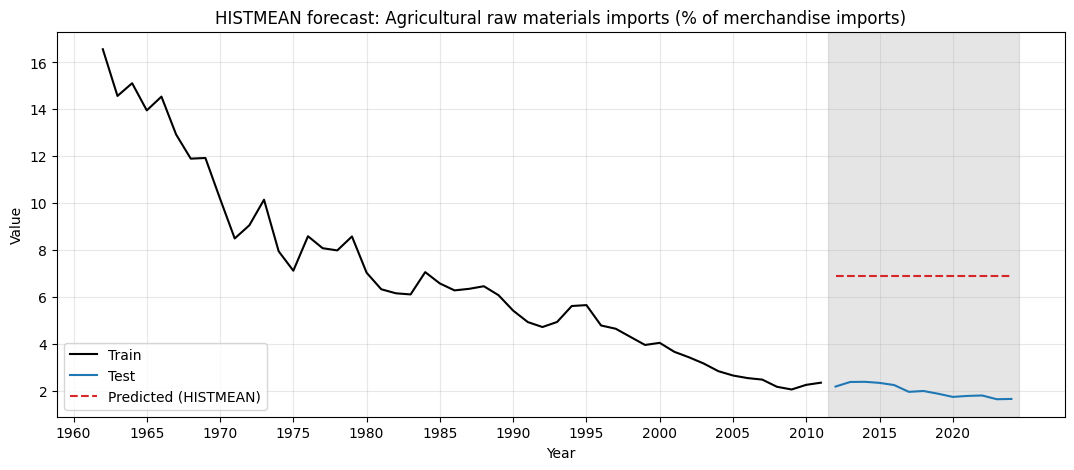

Agriculture, forestry, and fishing, value added (% of GDP) - historical mean (train 28 values): 2.3810096927937603


{'RMSE': np.float64(0.4963), 'MAE': 0.4921, 'MAPE': np.float64(26.19)}

RMSE (test 7 values): 0.4963
MAE (test 7 values): 0.4921
MAPE (test 7 values): 26.19%
Metriche salvate per HISTMEAN su Agriculture, forestry, and fishing, value added (% of GDP)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_valueadded_percent.png


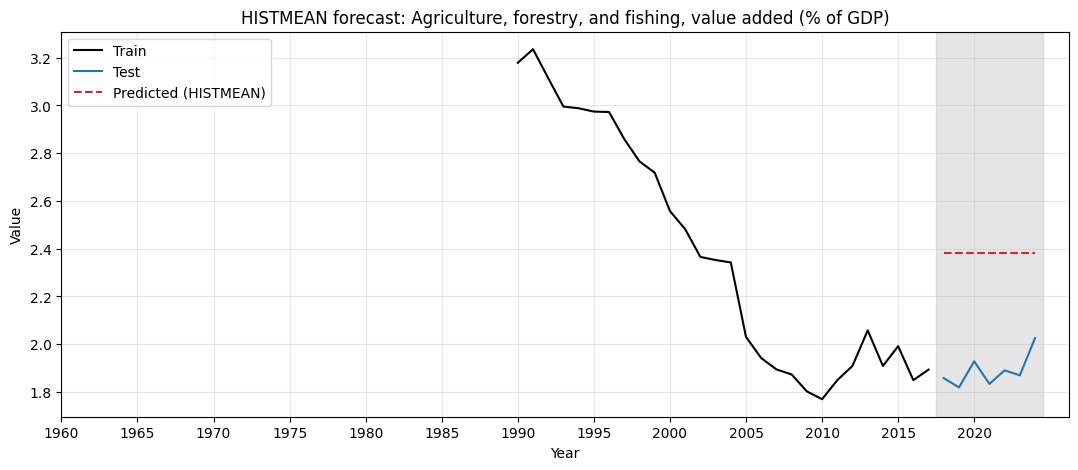

Agriculture, forestry, and fishing, value added (current US$) - historical mean (train 28 values): 37504794788.15178


{'RMSE': np.float64(4734567566.3351),
 'MAE': 3405777542.6699,
 'MAPE': np.float64(7.81)}

RMSE (test 7 values): 4734567566.3351
MAE (test 7 values): 3405777542.6699
MAPE (test 7 values): 7.81%
Metriche salvate per HISTMEAN su Agriculture, forestry, and fishing, value added (current US$)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_valueadded_dollars.png


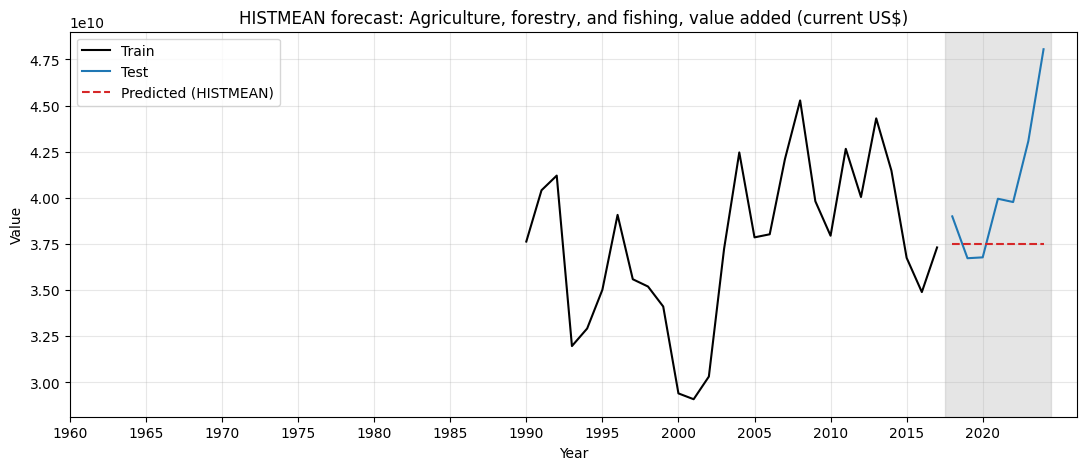

Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal) - historical mean (train 41 values): 49.39477804471707


{'RMSE': np.float64(1.2596), 'MAE': 0.9103, 'MAPE': np.float64(1.89)}

RMSE (test 11 values): 1.2596
MAE (test 11 values): 0.9103
MAPE (test 11 values): 1.89%
Metriche salvate per HISTMEAN su Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_withdrawals_percent.png


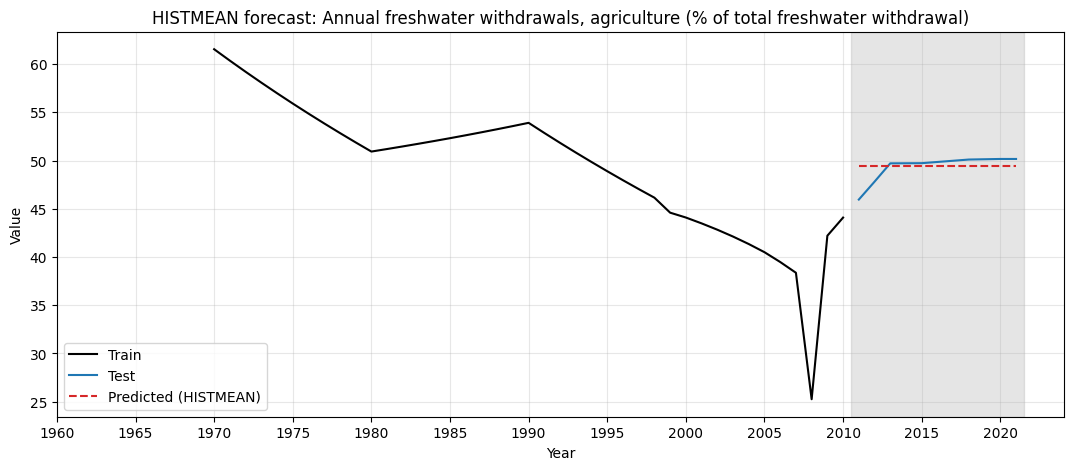

Arable land (% of land area) - historical mean (train 49 values): 32.18431305213388


{'RMSE': np.float64(8.908), 'MAE': 8.8817, 'MAPE': np.float64(38.23)}

RMSE (test 13 values): 8.908
MAE (test 13 values): 8.8817
MAPE (test 13 values): 38.23%
Metriche salvate per HISTMEAN su Arable land (% of land area)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_arableland_percent.png


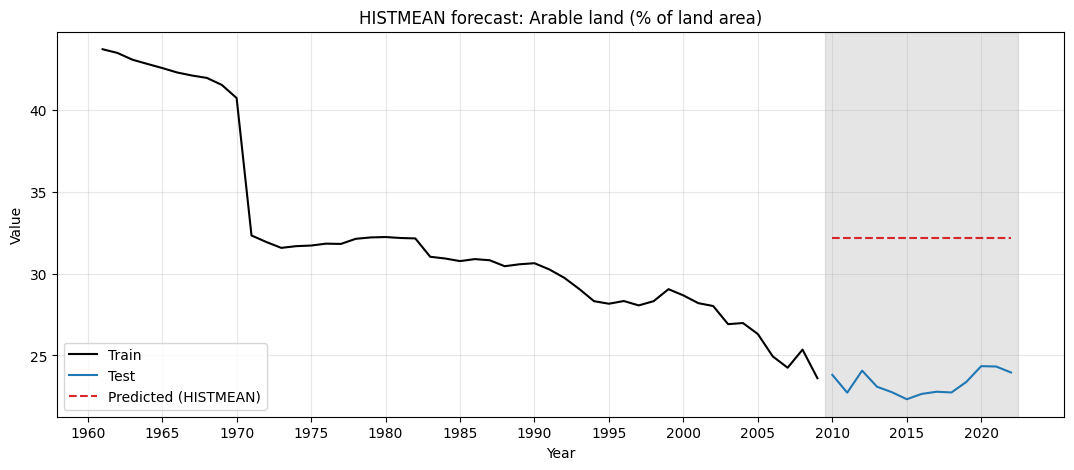

Arable land (hectares per person) - historical mean (train 48 values): 0.1722436642055956


{'RMSE': np.float64(0.0575), 'MAE': 0.0574, 'MAPE': np.float64(50.1)}

RMSE (test 13 values): 0.0575
MAE (test 13 values): 0.0574
MAPE (test 13 values): 50.10%
Metriche salvate per HISTMEAN su Arable land (hectares per person)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_arableland_person.png


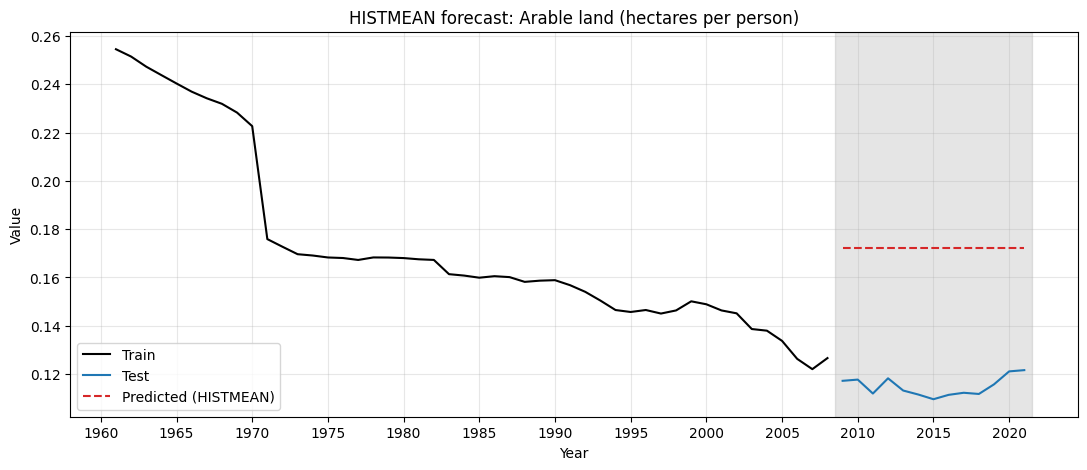

Arable land (hectares) - historical mean (train 48 values): 9526312.5


{'RMSE': np.float64(2650557.0734),
 'MAE': 2643260.2692,
 'MAPE': np.float64(38.51)}

RMSE (test 13 values): 2650557.0734
MAE (test 13 values): 2643260.2692
MAPE (test 13 values): 38.51%
Metriche salvate per HISTMEAN su Arable land (hectares)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_arableland_abs.png


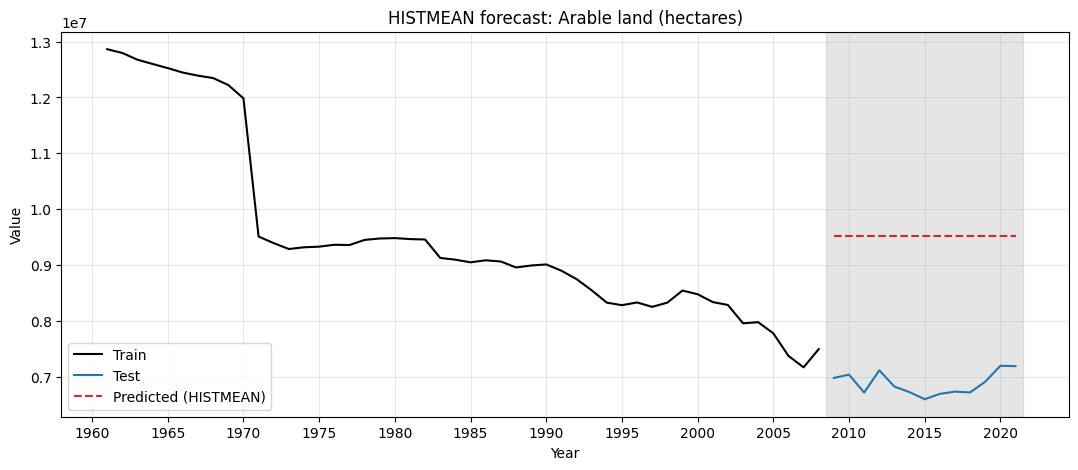

Cereal production (metric tons) - historical mean (train 49 values): 17934649.18367347


{'RMSE': np.float64(1491122.479),
 'MAE': 1208538.0295,
 'MAPE': np.float64(7.27)}

RMSE (test 13 values): 1491122.479
MAE (test 13 values): 1208538.0295
MAPE (test 13 values): 7.27%
Metriche salvate per HISTMEAN su Cereal production (metric tons)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_cereal_production.png


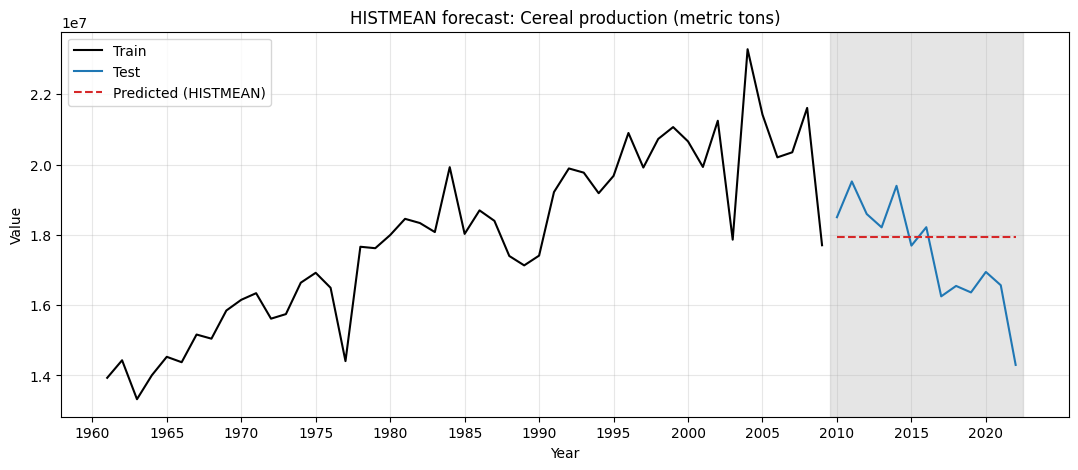

Cereal yield (kg per hectare) - historical mean (train 49 values): 3834.3306122448976


{'RMSE': np.float64(1577.677), 'MAE': 1557.9155, 'MAPE': np.float64(28.73)}

RMSE (test 13 values): 1577.677
MAE (test 13 values): 1557.9155
MAPE (test 13 values): 28.73%
Metriche salvate per HISTMEAN su Cereal yield (kg per hectare)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_cerealyield_abs.png


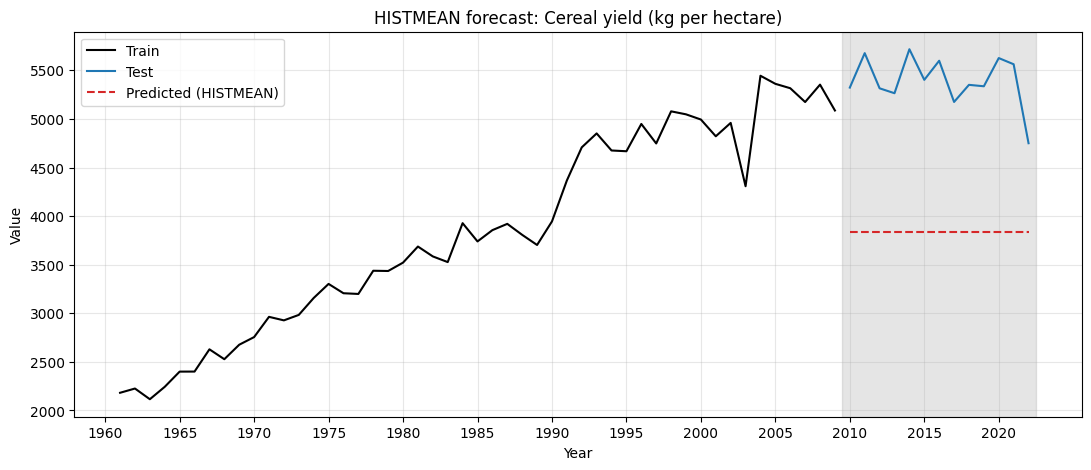

Crop production index (2014-2016 = 100) - historical mean (train 49 values): 111.12938775510206


{'RMSE': np.float64(12.802), 'MAE': 11.8563, 'MAPE': np.float64(12.2)}

RMSE (test 13 values): 12.802
MAE (test 13 values): 11.8563
MAPE (test 13 values): 12.20%
Metriche salvate per HISTMEAN su Crop production index (2014-2016 = 100)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_crop_production_index.png


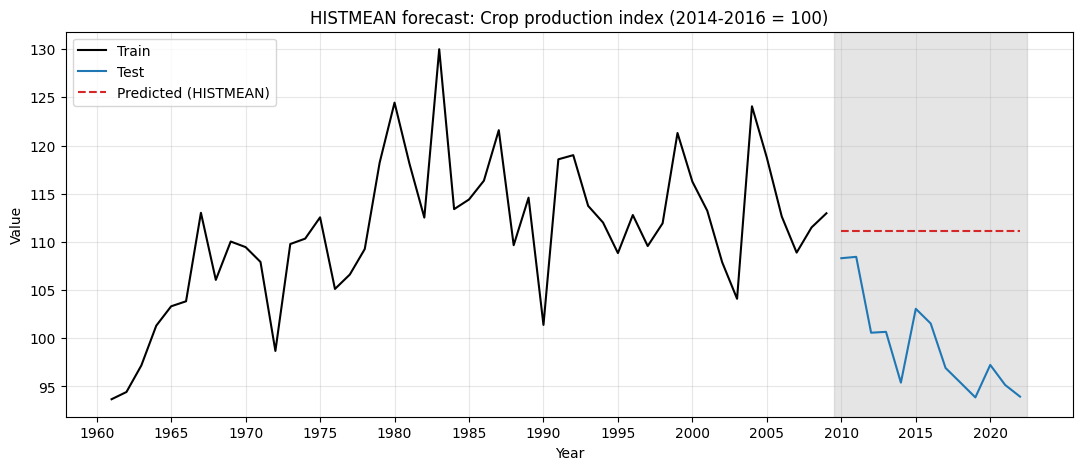

Employment in agriculture (% of total employment) - historical mean (train 26 values): 5.010655435052986


{'RMSE': np.float64(1.1843), 'MAE': 1.1758, 'MAPE': np.float64(30.84)}

RMSE (test 7 values): 1.1843
MAE (test 7 values): 1.1758
MAPE (test 7 values): 30.84%
Metriche salvate per HISTMEAN su Employment in agriculture (% of total employment)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_employment_tot.png


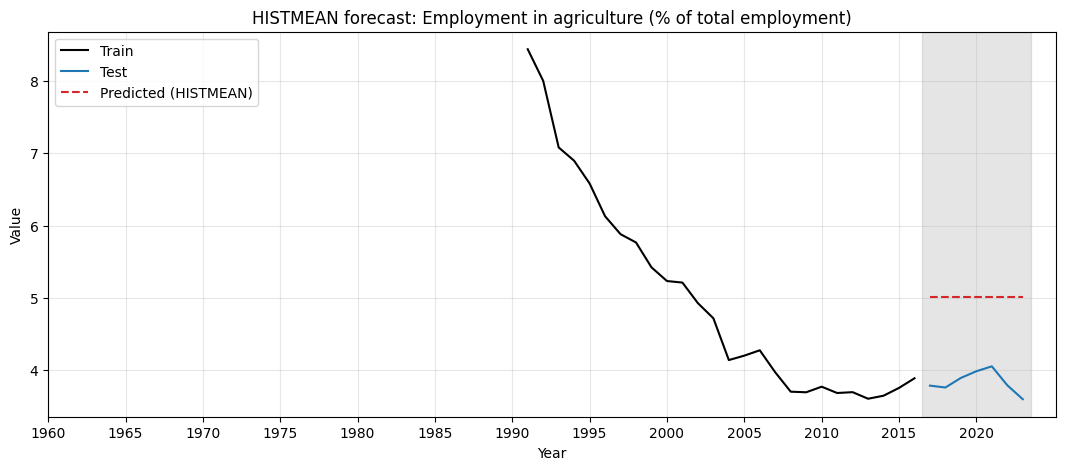

Employment in agriculture, female (% of female employment) - historical mean (train 26 values): 4.251096338286056


{'RMSE': np.float64(1.8927), 'MAE': 1.8909, 'MAPE': np.float64(80.35)}

RMSE (test 7 values): 1.8927
MAE (test 7 values): 1.8909
MAPE (test 7 values): 80.35%
Metriche salvate per HISTMEAN su Employment in agriculture, female (% of female employment)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_employment_female.png


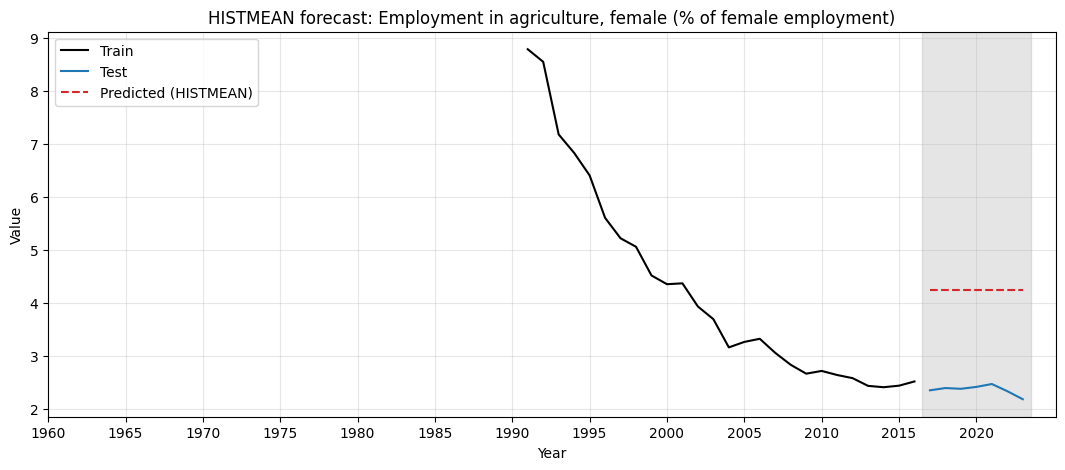

Employment in agriculture, male (% of male employment) - historical mean (train 26 values): 5.5105655087467325


{'RMSE': np.float64(0.6382), 'MAE': 0.61, 'MAPE': np.float64(12.61)}

RMSE (test 7 values): 0.6382
MAE (test 7 values): 0.61
MAPE (test 7 values): 12.61%
Metriche salvate per HISTMEAN su Employment in agriculture, male (% of male employment)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_employment_male.png


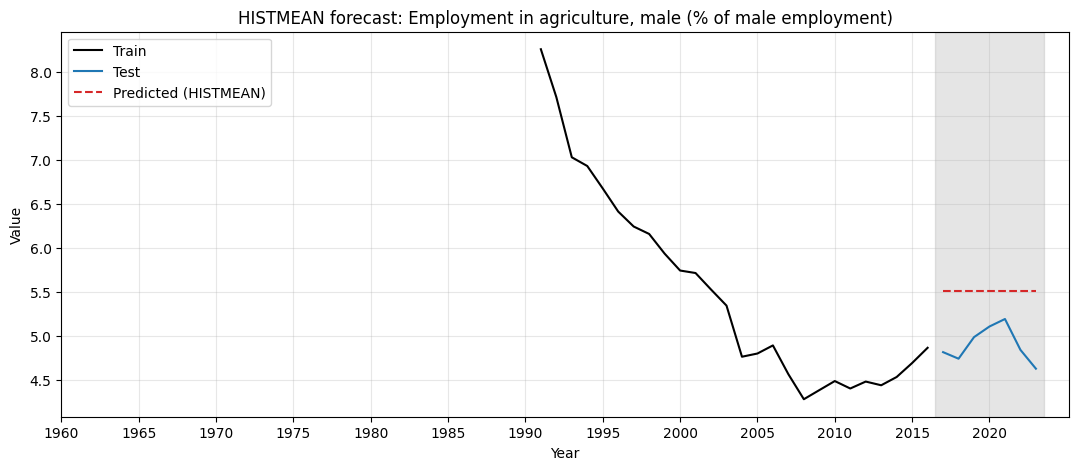

Fertilizer consumption (% of fertilizer production) - historical mean (train 49 values): 171.63685046272573


{'RMSE': np.float64(89.9853), 'MAE': 74.8262, 'MAPE': np.float64(38.99)}

RMSE (test 13 values): 89.9853
MAE (test 13 values): 74.8262
MAPE (test 13 values): 38.99%
Metriche salvate per HISTMEAN su Fertilizer consumption (% of fertilizer production)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_fertilizer_percent.png


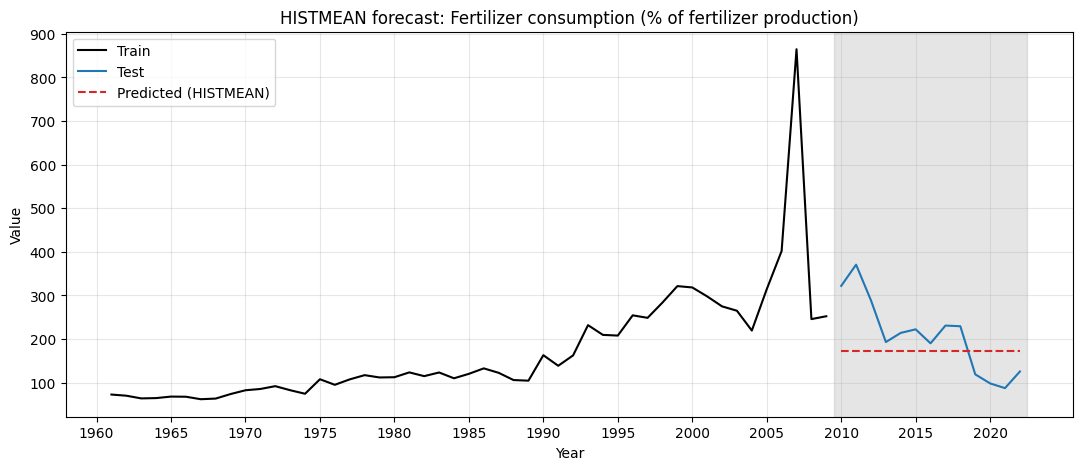

Fertilizer consumption (kilograms per hectare of arable land) - historical mean (train 49 values): 175.62522529664352


{'RMSE': np.float64(49.5005), 'MAE': 49.0597, 'MAPE': np.float64(39.16)}

RMSE (test 13 values): 49.5005
MAE (test 13 values): 49.0597
MAPE (test 13 values): 39.16%
Metriche salvate per HISTMEAN su Fertilizer consumption (kilograms per hectare of arable land)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_fertilizer_abs.png


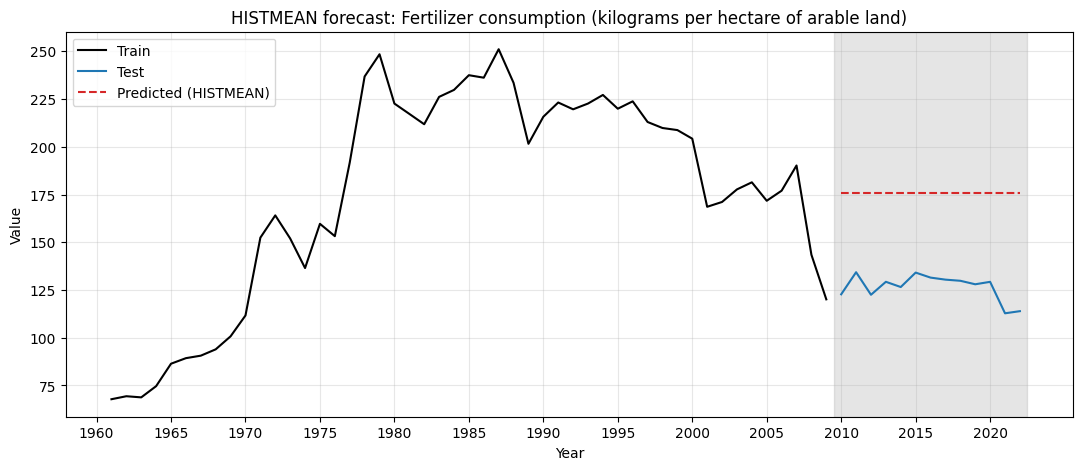

Food production index (2014-2016 = 100) - historical mean (train 49 values): 106.05693877551022


{'RMSE': np.float64(6.2587), 'MAE': 5.671, 'MAPE': np.float64(5.71)}

RMSE (test 13 values): 6.2587
MAE (test 13 values): 5.671
MAPE (test 13 values): 5.71%
Metriche salvate per HISTMEAN su Food production index (2014-2016 = 100)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_food_production_index.png


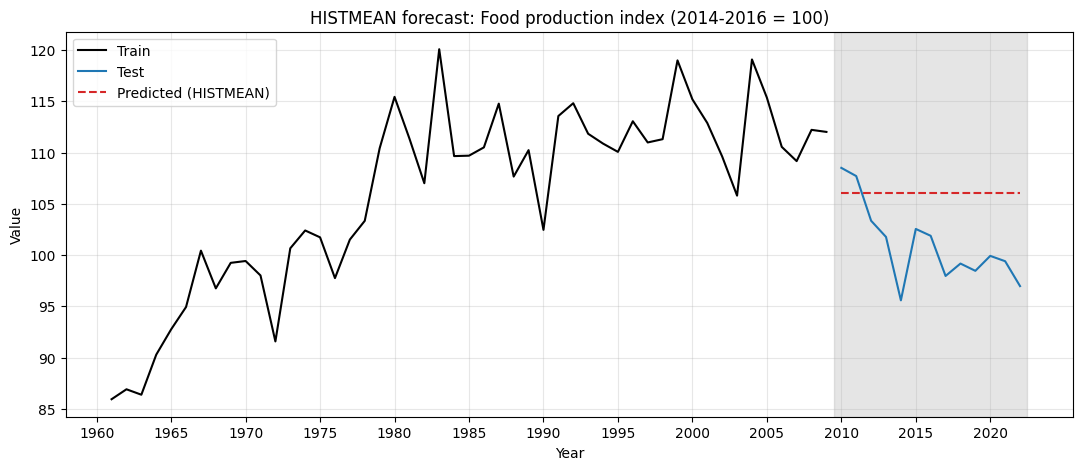

Forest area (% of land area) - historical mean (train 26 values): 28.804963443645565


{'RMSE': np.float64(3.3816), 'MAE': 3.3619, 'MAPE': np.float64(10.44)}

RMSE (test 7 values): 3.3816
MAE (test 7 values): 3.3619
MAPE (test 7 values): 10.44%
Metriche salvate per HISTMEAN su Forest area (% of land area)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_forestarea_percent.png


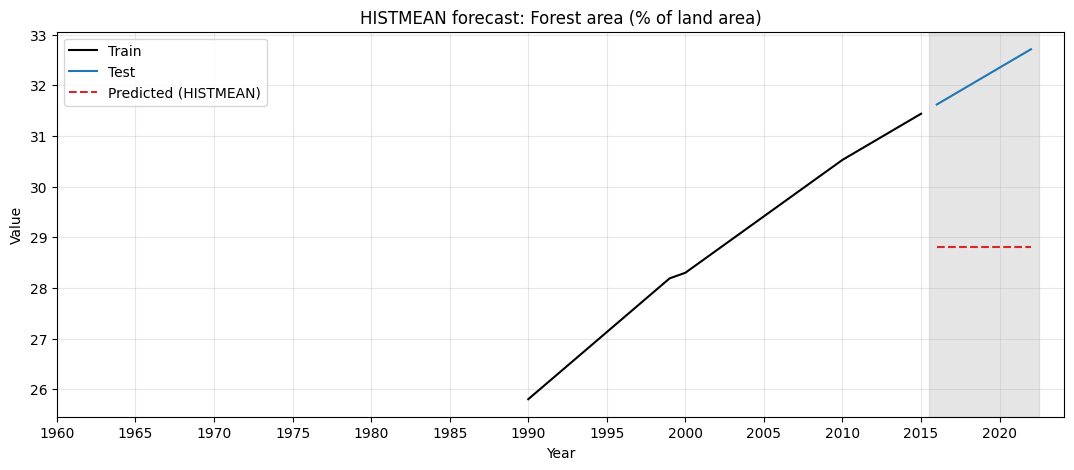

Forest area (sq. km) - historical mean (train 26 values): 85014.48653846154


{'RMSE': np.float64(10165.8396), 'MAE': 10108.7135, 'MAPE': np.float64(10.62)}

RMSE (test 7 values): 10165.8396
MAE (test 7 values): 10108.7135
MAPE (test 7 values): 10.62%
Metriche salvate per HISTMEAN su Forest area (sq. km)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_forestarea_abs.png


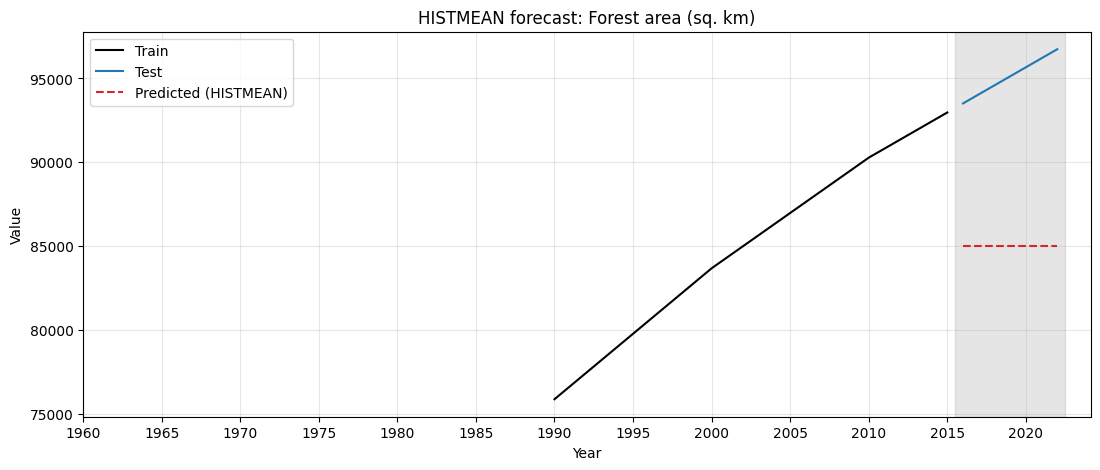

Land under cereal production (hectares) - historical mean (train 49 values): 4872527.8367346935


{'RMSE': np.float64(1645417.9467),
 'MAE': 1634397.1444,
 'MAPE': np.float64(50.99)}

RMSE (test 13 values): 1645417.9467
MAE (test 13 values): 1634397.1444
MAPE (test 13 values): 50.99%
Metriche salvate per HISTMEAN su Land under cereal production (hectares)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_cerealland_abs.png


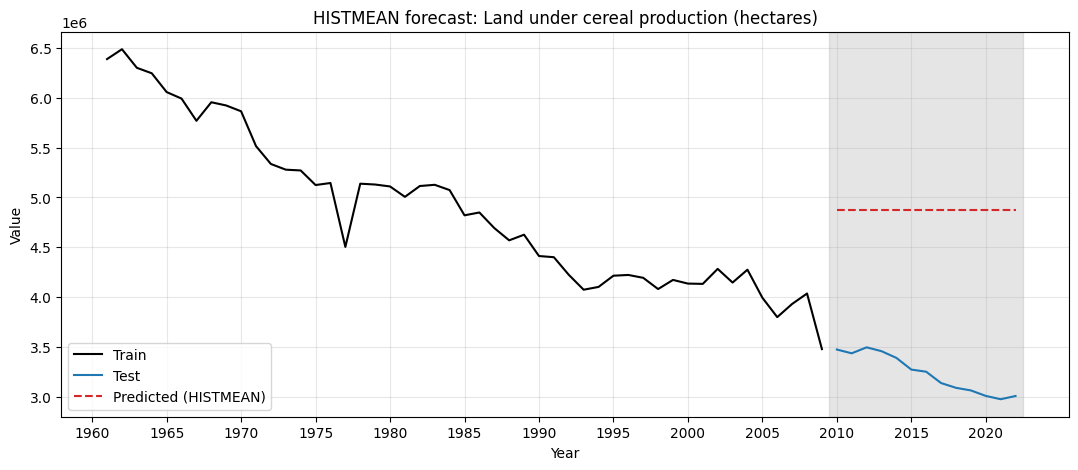

Livestock production index (2014-2016 = 100) - historical mean (train 49 values): 97.32183673469389


{'RMSE': np.float64(7.9306), 'MAE': 7.2338, 'MAPE': np.float64(6.83)}

RMSE (test 13 values): 7.9306
MAE (test 13 values): 7.2338
MAPE (test 13 values): 6.83%
Metriche salvate per HISTMEAN su Livestock production index (2014-2016 = 100)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_livestock_production_index.png


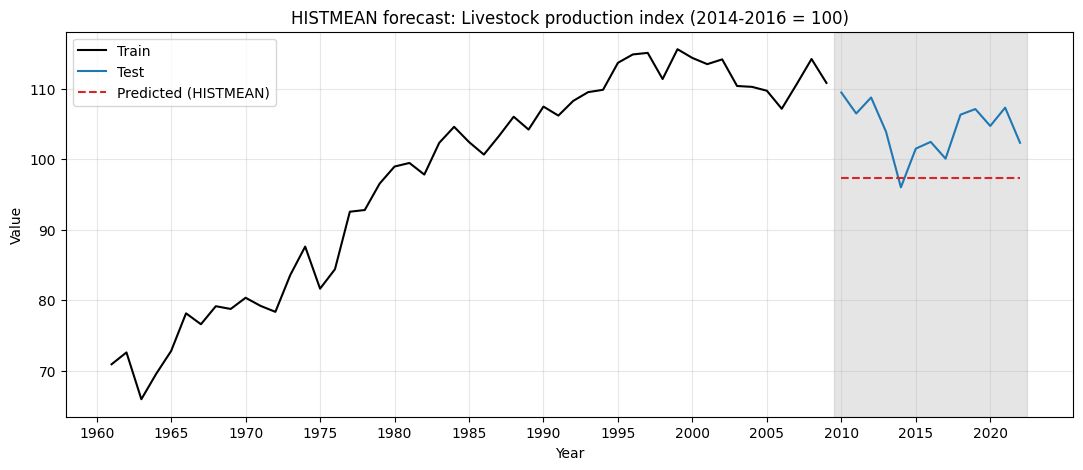

Permanent cropland (% of land area) - historical mean (train 49 values): 9.643117282946234


{'RMSE': np.float64(1.5853), 'MAE': 1.5333, 'MAPE': np.float64(19.21)}

RMSE (test 13 values): 1.5853
MAE (test 13 values): 1.5333
MAPE (test 13 values): 19.21%
Metriche salvate per HISTMEAN su Permanent cropland (% of land area)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_cropland_percent.png


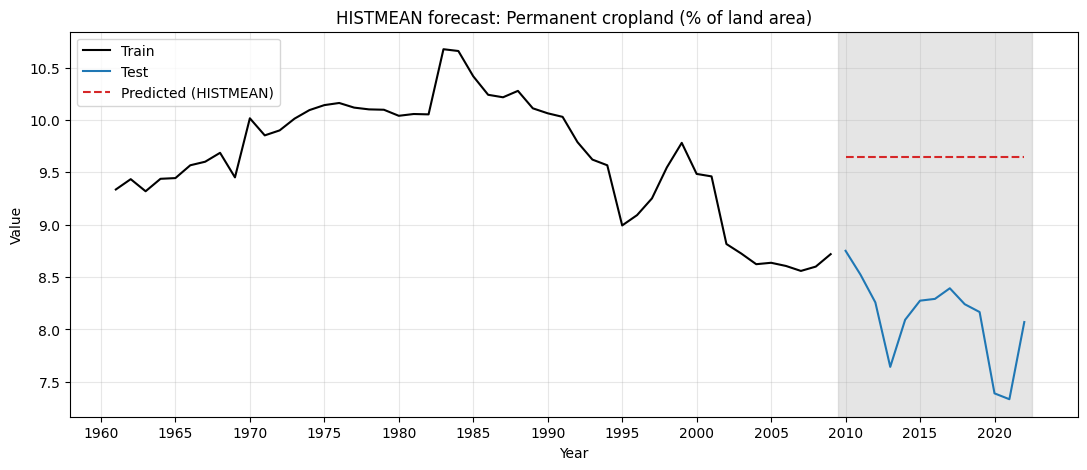

Rural population - historical mean (train 52 values): 19052926.634615384


{'RMSE': np.float64(1620364.5486),
 'MAE': 1400345.8654,
 'MAPE': np.float64(8.17)}

RMSE (test 13 values): 1620364.5486
MAE (test 13 values): 1400345.8654
MAPE (test 13 values): 8.17%
Metriche salvate per HISTMEAN su Rural population
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_population_abs.png


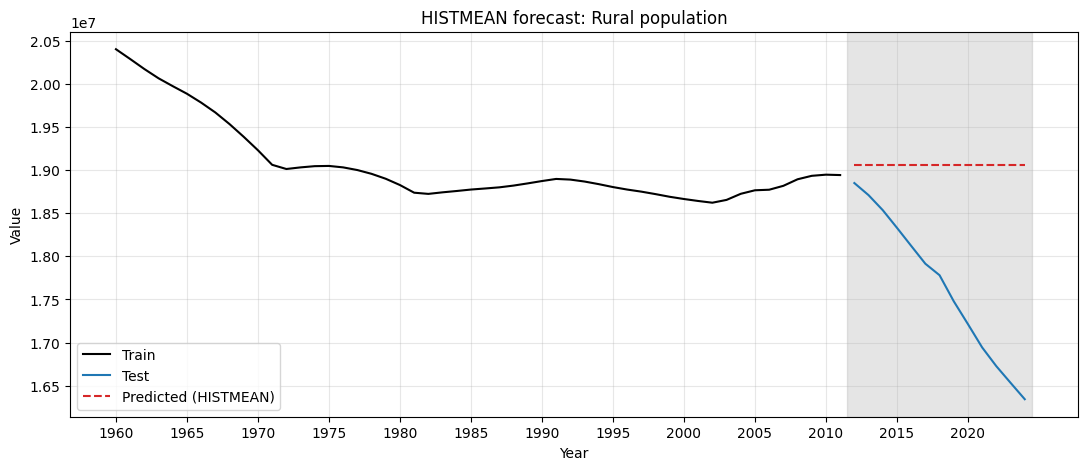

Rural population (% of total population) - historical mean (train 52 values): 34.20125


{'RMSE': np.float64(4.7939), 'MAE': 4.6613, 'MAPE': np.float64(15.95)}

RMSE (test 13 values): 4.7939
MAE (test 13 values): 4.6613
MAPE (test 13 values): 15.95%
Metriche salvate per HISTMEAN su Rural population (% of total population)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_population_percent.png


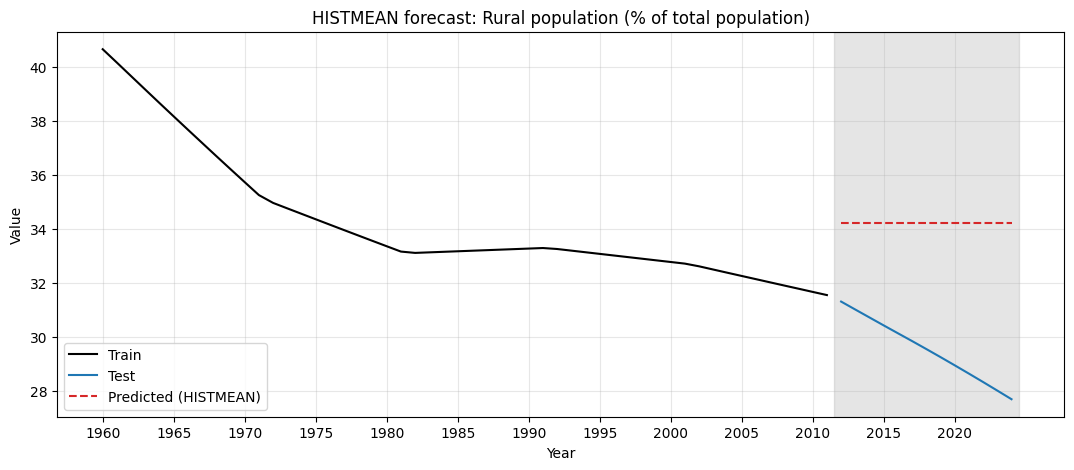

Rural population growth (annual %) - historical mean (train 51 values): -0.14545428021041765


{'RMSE': np.float64(1.0451), 'MAE': 0.9894, 'MAPE': np.float64(85.67)}

RMSE (test 13 values): 1.0451
MAE (test 13 values): 0.9894
MAPE (test 13 values): 85.67%
Metriche salvate per HISTMEAN su Rural population growth (annual %)
Grafico salvato in: results/plots/HISTMEAN\HISTMEAN_population_growth.png


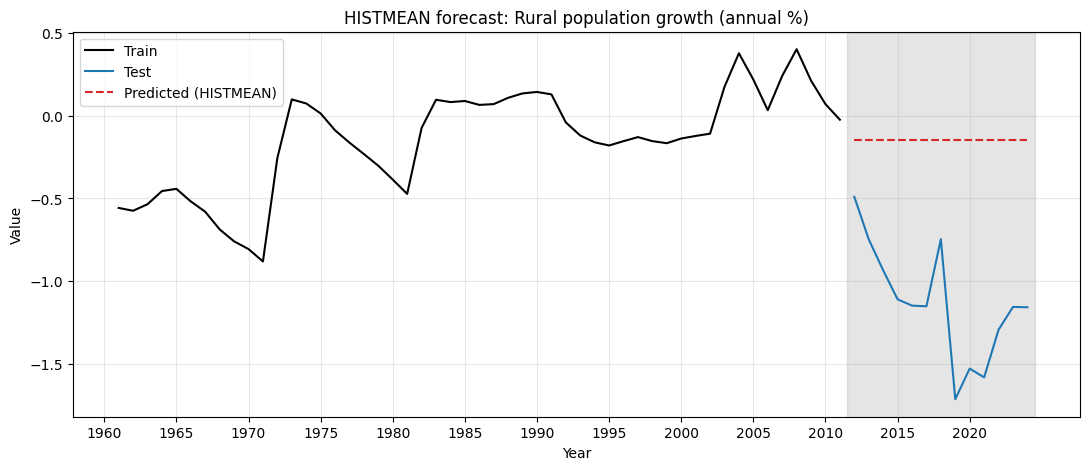

In [24]:
for col in df.columns:
    if col == 'Year':
        continue
    if not np.issubdtype(df[col].dtype, np.number):
        print(f"Skipping {col}: non-numeric dtype")
        continue
    if df[col].dropna().empty:
        print(f"Skipping {col}: all NaN")
        continue
    
    train, test = historical_mean(col, df)
    metrics = utils.evaluate_forecast(test['Value'].values, test['pred_mean'].values)
    display(metrics)
    print(f"RMSE (test {len(test)} values): {metrics['RMSE']}")
    print(f"MAE (test {len(test)} values): {metrics['MAE']}")
    print(f"MAPE (test {len(test)} values): {metrics['MAPE']:.2f}%")
    utils.save_metrics(model_name="HISTMEAN", variable_name=col, metrics=metrics)
    utils.plot_results(df, train.dropna(), test.dropna(), test['pred_mean'].dropna(), "HISTMEAN", col, metrics['RMSE'])